In [1]:
# AudioPython
#
# sample code to play audio through Python
# based on "soundcard",
# https://pypi.org/project/SoundCard/
# https://soundcard.readthedocs.io/en/latest/
# can be installed from anaconda prompt with "pip install soundcard"

# note: depending on your hardware, you might need to change the sample rate
# e.g, my laptop soundcard won't play at 48000 Hz, but 44100 Hz works nicely
# my focusrite soundcard plays 48000 nicely

import soundcard as sc
import numpy as np

# for wav-file input/output
from scipy.io import wavfile
import scipy.io

import matplotlib.pyplot as plt

## Problem 2.1

### (a)

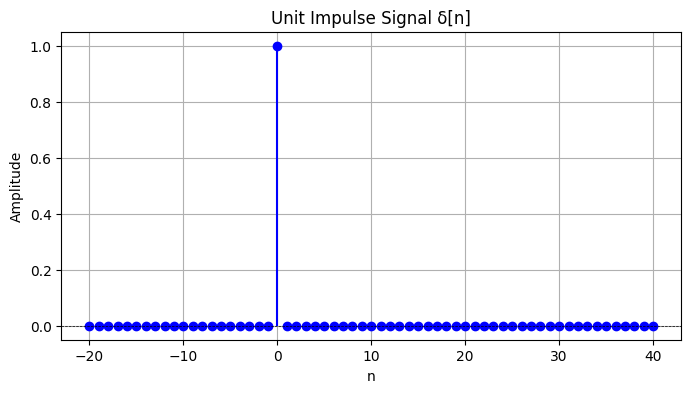

In [ ]:
n_min = -20
n_max = 40
n = np.arange(n_min, n_max+1)

# Create the unit impulse signal
# The impulse is 1 at n = 0 and 0 elsewhere
delta = np.where(n == 0, 1, 0)

# Plot the unit impulse signal
fig, ax = plt.subplots()
ax.stem(n, delta, basefmt=" ", linefmt='b-', markerfmt='bo')
ax.set_title("Unit Impulse Signal δ[n]")
ax.set_xlabel("n")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.show()

### (b)

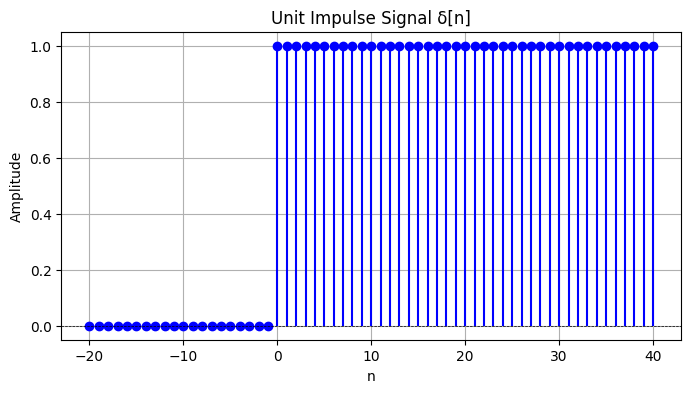

In [ ]:
u = np.where(n >= 0, 1, 0)

# Plot the unit impulse signal
fig, ax = plt.subplots()
ax.stem(n, u, basefmt=" ", linefmt='b-', markerfmt='bo')
ax.set_title("Unit Impulse Signal δ[n]")
ax.set_xlabel("n")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.show()

### (c)

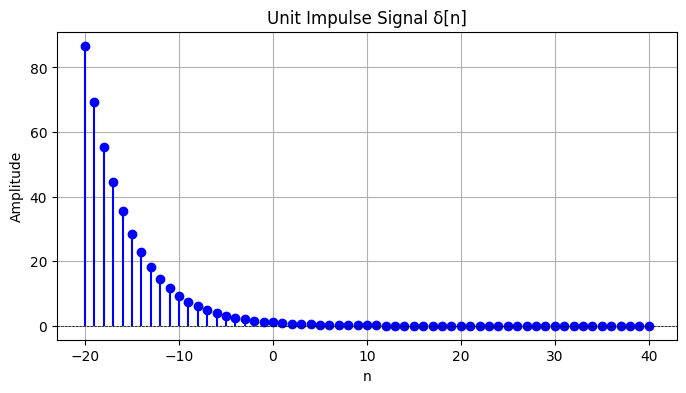

In [17]:
x1 = 0.80**n

# Plot the unit impulse signal
fig, ax = plt.subplots()
ax.stem(n, x1, basefmt=" ", linefmt='b-', markerfmt='bo')
ax.set_title("Unit Impulse Signal δ[n]")
ax.set_xlabel("n")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.show()

### (d)

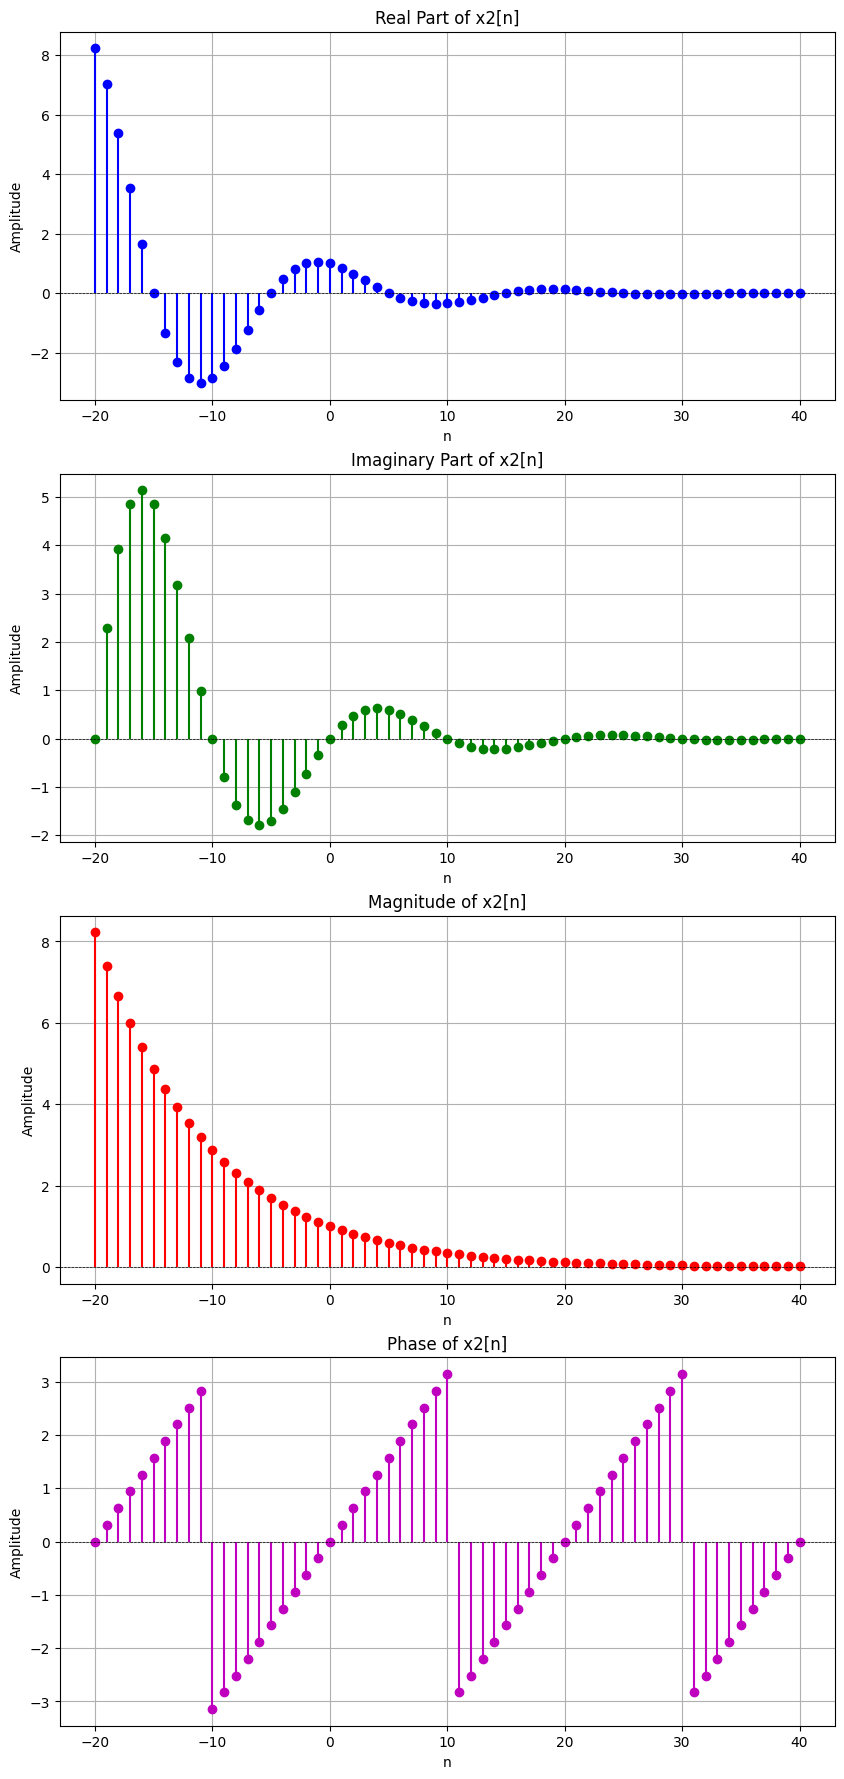

In [31]:
x2 = (0.9*np.exp(1j * np.pi/10))**n

fig, axs = plt.subplots(4, 1, figsize=(10, 22))

# Real part
axs[0].stem(n, np.real(x2), basefmt=" ", linefmt='b-', markerfmt='bo')
axs[0].set_title("Real Part of x2[n]")
axs[0].set_xlabel("n")
axs[0].set_ylabel("Amplitude")
axs[0].grid(True)
axs[0].axhline(0, color='black', linewidth=0.5, linestyle='--')

# Imaginary part
axs[1].stem(n, np.imag(x2), basefmt=" ", linefmt='g-', markerfmt='go')
axs[1].set_title("Imaginary Part of x2[n]")
axs[1].set_xlabel("n")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True)
axs[1].axhline(0, color='black', linewidth=0.5, linestyle='--')

# Magnitude
axs[2].stem(n, np.abs(x2), basefmt=" ", linefmt='r-', markerfmt='ro')
axs[2].set_title("Magnitude of x2[n]")
axs[2].set_xlabel("n")
axs[2].set_ylabel("Amplitude")
axs[2].grid(True)
axs[2].axhline(0, color='black', linewidth=0.5, linestyle='--')

# Phase
axs[3].stem(n, np.angle(x2), basefmt=" ", linefmt='m-', markerfmt='mo')
axs[3].set_title("Phase of x2[n]")
axs[3].set_xlabel("n")
axs[3].set_ylabel("Amplitude")
axs[3].grid(True)
axs[3].axhline(0, color='black', linewidth=0.5, linestyle='--')

### (e)

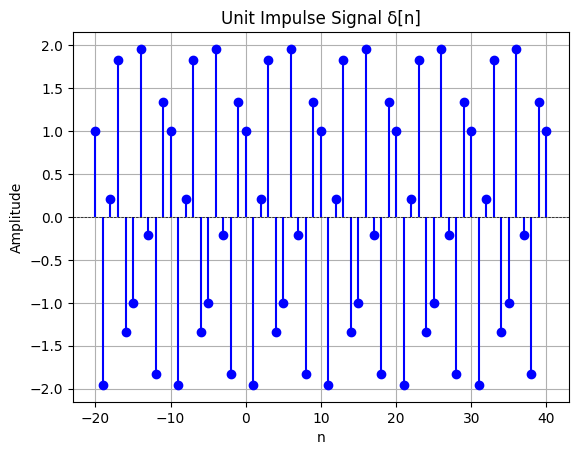

In [ ]:
x3 = 2*np.cos(2*np.pi*0.3*n + np.pi/3)

# Plot the unit impulse signal
fig, ax = plt.subplots()
ax.stem(n, x3, basefmt=" ", linefmt='b-', markerfmt='bo')
ax.set_title("Unit Impulse Signal δ[n]")
ax.set_xlabel("n")
ax.set_ylabel("Amplitude")
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.show()

## Problem 2.2

### (a) and (b)

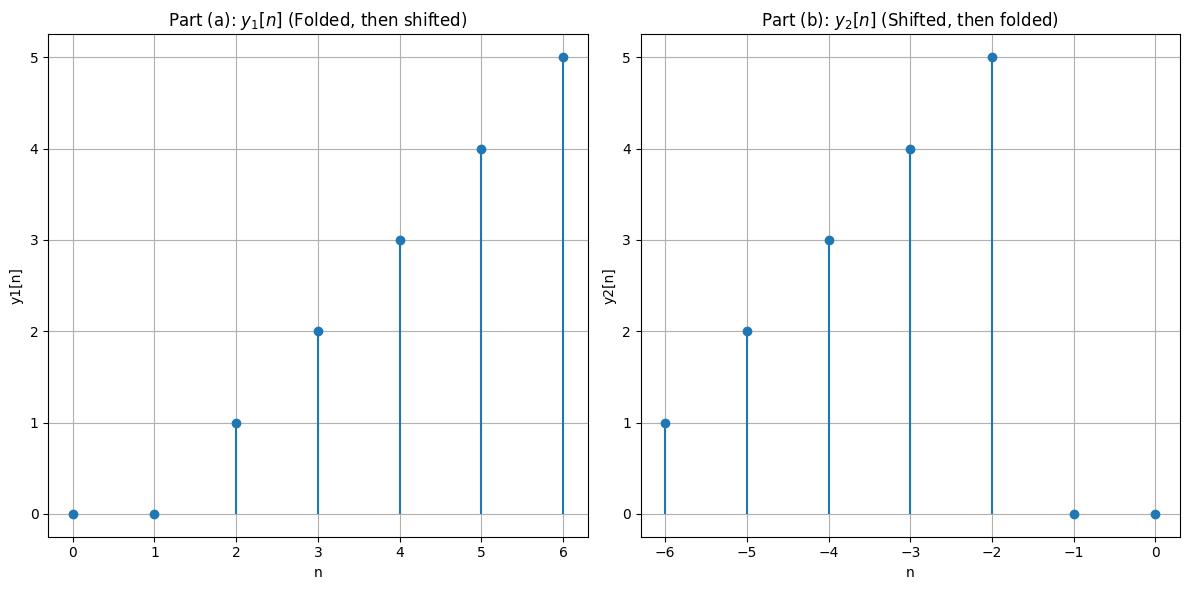

In [55]:
# Define the original signal x[n]
x = np.flip(np.arange(1, 6))  # [5, 4, 3, 2, 1]
n_x = np.arange(0, len(x))  # Index range for x[n]

# Part (a): Folding first, then shifting
# Folded signal (x[-n])
x_folded = np.flip(x)  # Reverse the signal

# Shift folded signal 2 samples to the right
y1 = [0, 0] + x_folded
n_y1 = np.arange(0, len(y1))  # Index range for y1[n]

# Part (b): Shifting first, then folding
# Shifted signal (x[n-2])
x_shifted = [0, 0] + x
n_shifted = np.arange(-2, len(x) + 2 - 2)  # Adjust indices for shift

# Fold the shifted signal (x[2-n])
y2 = x_shifted[::-1]
n_y2 = np.arange(-len(y2) + 1, 1)  # Index range for y2[n]

# Plot the results
plt.figure(figsize=(12, 6))

# Plot for y1[n]
plt.subplot(1, 2, 1)
plt.stem(n_y1, y1, basefmt=" ")
plt.title(r"Part (a): $y_1[n]$ (Folded, then shifted)")
plt.xlabel("n")
plt.ylabel("y1[n]")
plt.grid(True)

# Plot for y2[n]
plt.subplot(1, 2, 2)
plt.stem(n_y2, y2, basefmt=" ")
plt.title(r"Part (b): $y_2[n]$ (Shifted, then folded)")
plt.xlabel("n")
plt.ylabel("y2[n]")
plt.grid(True)

plt.tight_layout()
plt.show()


### (c)

They are not the same signals. $y_2[n]$ is correct since you have to shift first when doing operations on signals.

## Problem 2.4

### (a)

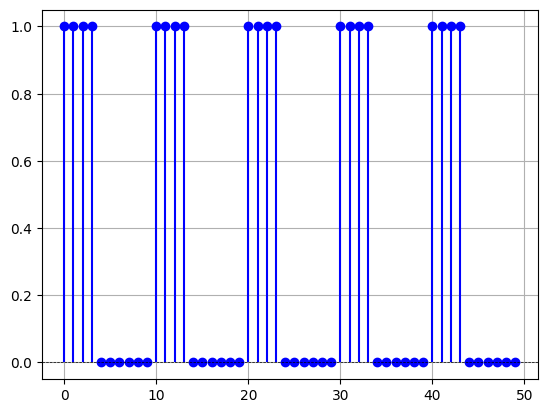

In [ ]:
period = np.array([1,1,1,1,0,0,0,0,0,0])
sequence = np.tile(period, 5)
n_seq = np.arange(0, len(sequence))

fig, ax = plt.subplots()
ax.stem(n_seq, sequence, basefmt=" ", linefmt='b-', markerfmt='bo')
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

### (b)

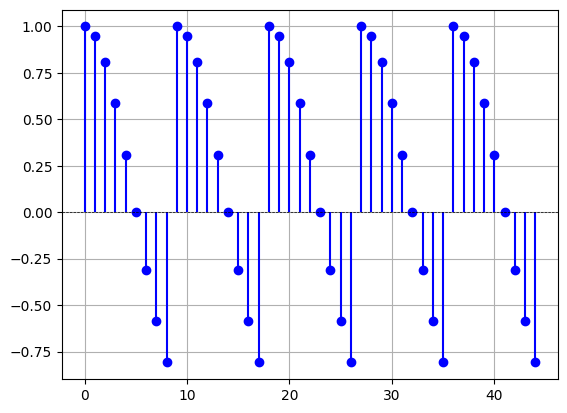

In [60]:
n = np.arange(0, 9)
period = np.cos(0.1 * np.pi * n)
sequence = np.tile(period, 5)
n_seq = np.arange(0, len(sequence))

fig, ax = plt.subplots()
ax.stem(n_seq, sequence, basefmt=" ", linefmt='b-', markerfmt='bo')
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

### (c)

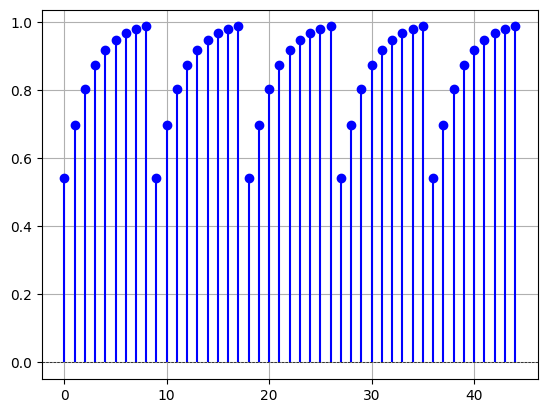

In [61]:
n = np.arange(0, 9)
period = np.cos(0.8**n)
sequence = np.tile(period, 5)
n_seq = np.arange(0, len(sequence))

fig, ax = plt.subplots()
ax.stem(n_seq, sequence, basefmt=" ", linefmt='b-', markerfmt='bo')
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

## Problem 2.5

### (a)

It is known that the signal is periodic with an integer period $N$ if $\cos(\omega_{0} (n + N) + \theta_{0}) = \cos(\omega_{0} n + \theta_{0} + \omega_{0} N) = \cos(\omega_{0} n + \theta_{0})$. This is true if $\omega_{0}N$ is an integer multiple of $2\pi$. If the integer is called $M$ the following has to be true
$$
\omega_{0}N = 2\pi M
$$
Now isolating the normalized frequency
$$
\frac{w_{0}}{2\pi} = \frac{M}{N}
$$
It can be seen that it is equal to a fraction of two integers, which will always be in the rational domain.

### (b)

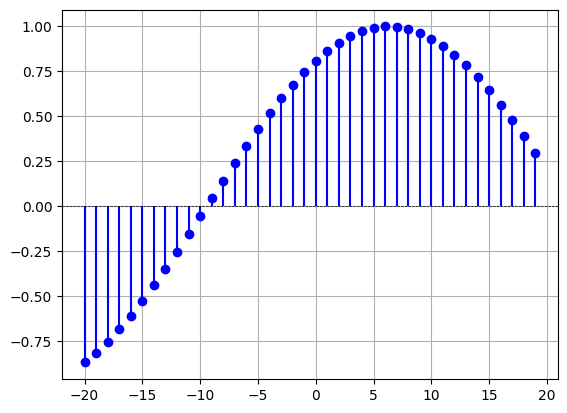

In [62]:
n = np.arange(-20, 20)
x = np.cos(0.1 * n - np.pi/5)

fig, ax = plt.subplots()
ax.stem(n, x, basefmt=" ", linefmt='b-', markerfmt='bo')
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

This sequence is not periodic since $\frac{0.1}{2 \pi}$ is not a rational number. Periodicity cannot be concluded from a plot, since it could contain a small shift somewhere between two wave tops. This would make it not periodic in discrete time. 

### (c)

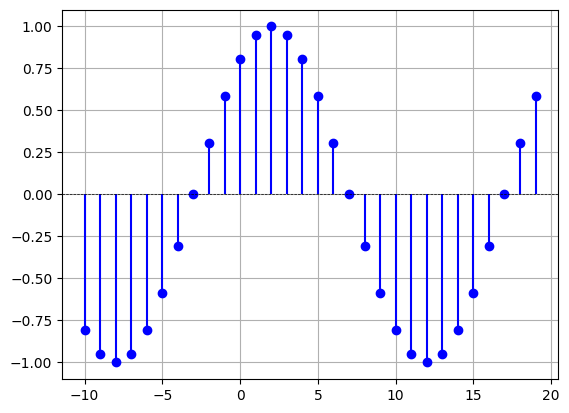

In [10]:
n = np.arange(-10, 20)
x = np.cos(0.1 * np.pi * n - np.pi/5)

fig, ax = plt.subplots()
ax.stem(n, x, basefmt=" ", linefmt='b-', markerfmt='bo')
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

It is periodic since $\frac{0.1\pi}{2\pi} = \frac{0.1}{2} = 0.05$ is a rational number. The fundamental period can be calculated by isolating $N$ and finding the smallest nonzero integer $M$ that solves the following equation

\begin{align*}
0.1\pi N &= 2 \pi M\\
N &= 20 M\\
N &= 20
\end{align*}

The signal has a fundamental period of 20. $N$ is then the fundamental period while $M$ is the number of sinusoid cycles there is before the signal repeats.

## Problem 2.6

### (a)

In [13]:
# get a list of all speakers:
speakers = sc.all_speakers()
# get the current default speaker on your system:
default_speaker = sc.default_speaker()
# get a list of all microphones:
mics = sc.all_microphones()
# get the current default microphone on your system:
default_mic = sc.default_microphone()

datasamplerate, data = wavfile.read('sample-3s.wav')
data=data/32768 # the data are 16 bits integers and must be scaled to the -1:1 range
default_speaker.play(data, samplerate=datasamplerate)

### (b)

In [ ]:
data_half = data[0::2] # take every second sample
datasamplerate_half = datasamplerate/2
default_speaker.play(data_half, samplerate=datasamplerate_half)

### (c)

In [ ]:
data_quarter = data[0::2] # take every second sample
datasamplerate_quarter = datasamplerate/2
default_speaker.play(data_half, samplerate=datasamplerate_quarter)

### (d)

In [ ]:
wavfile.write('sample-3s-quarter.wav', datasamplerate_quarter, data_quarter)

## Problem 2.9

### (a)

### (b)